In [9]:
# Cell 1: Import Libraries and Set Configurations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styling
sns.set_theme(style="whitegrid")
%matplotlib inline

# ==========================================
# Dataset Loading (Q1)
# ==========================================
# Cell 2: Load the dataset
print("--- Q1: Loading Dataset ---")
df = pd.read_csv("Amazon.csv")
df.head()

--- Q1: Loading Dataset ---


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [10]:
# Cell 3: Dataset Overview (Q2)
print("--- Q2: Dataset Overview ---")
print(f"Number of rows and columns: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary of Numerical Columns:")
print(df.describe())

--- Q2: Dataset Overview ---
Number of rows and columns: (100000, 20)

Column Names:
['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID']

Data Types:
OrderID           object
OrderDate         object
CustomerID        object
CustomerName      object
ProductID         object
ProductName       object
Category          object
Brand             object
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod     object
OrderStatus       object
City              object
State             object
Country           object
SellerID          object
dtype: object

Statistical Summary of Numerical Columns:
            Quantity      UnitPrice       Discount            Tax  \
count  100000.000000  100

In [12]:
# Data Engineering (Pre-computation for Profit & Time)
# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create Calculated Fields matching your Excel Logic
df['CostPrice'] = (df['Quantity'] * df['UnitPrice']) * (1 - df['Discount']) * 0.75
df['Profit'] = df['TotalAmount'] - df['CostPrice'] - df['Tax'] - df['ShippingCost']
df['Month_Year'] = df['OrderDate'].dt.to_period('M')

print("Data cleaning & feature engineering complete. Calculated 'Profit' & 'Month_Year' added.")

Data cleaning & feature engineering complete. Calculated 'Profit' & 'Month_Year' added.


In [13]:
# KPI Analysis (Q3)
print("--- Q3: KPI Analysis ---")
total_sales = df['TotalAmount'].sum()
total_profit = df['Profit'].sum()
total_orders = df['OrderID'].nunique()
avg_sales = df['TotalAmount'].mean()
avg_profit = df['Profit'].mean()
max_sales = df['TotalAmount'].max()
min_sales = df['TotalAmount'].min()

print(f"Total Sales:         ₹{total_sales:,.2f}")
print(f"Total Profit:        ₹{total_profit:,.2f}")
print(f"Total Orders:        {total_orders:,}")
print(f"Average Sales Value: ₹{avg_sales:,.2f}")
print(f"Average Profit Value:₹{avg_profit:,.2f}")
print(f"Maximum Order Value: ₹{max_sales:,.2f}")
print(f"Minimum Order Value: ₹{min_sales:,.2f}")

--- Q3: KPI Analysis ---
Total Sales:         ₹91,825,647.92
Total Profit:        ₹21,059,521.40
Total Orders:        100,000
Average Sales Value: ₹918.26
Average Profit Value:₹210.60
Maximum Order Value: ₹3,534.98
Minimum Order Value: ₹4.27


In [14]:
# Sales & Category Analysis (Q4, Q5, Q7)
print("--- Q4: Total Sales by State (Descending) ---")
state_sales = df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)
print(state_sales)

print("\n--- Q5: Total Sales by Category ---")
cat_sales = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
print(cat_sales)

print("\n--- Q7: Total Sales by Brand (Sub-Category Substitute) ---")
brand_sales = df.groupby('Brand')['TotalAmount'].sum().sort_values(ascending=False)
print(brand_sales)

--- Q4: Total Sales by State (Descending) ---
State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
NY     4554358.08
DC     4520876.11
AZ     4504324.19
Name: TotalAmount, dtype: float64

--- Q5: Total Sales by Category ---
Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64

--- Q7: Total Sales by Brand (Sub-Category Substitute) ---
Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64


In [15]:
# Customer & Product Analysis (Q9 & Q10)
print("--- Q9: Top 5 Customers Based on Total Sales ---")
top_customers = df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5)
print(top_customers)

print("\n--- Q10: Total Quantity Sold for Each Product (Top 10 Displayed) ---")
product_qty = df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False)
print(product_qty.head(10))

--- Q9: Top 5 Customers Based on Total Sales ---
CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Name: TotalAmount, dtype: float64

--- Q10: Total Quantity Sold for Each Product (Top 10 Displayed) ---
ProductName
LED Desk Lamp          6344
Water Bottle           6275
Memory Card 128GB      6240
Router                 6202
Board Game             6200
Microphone             6196
Gaming Mouse           6170
Electric Kettle        6165
Mechanical Keyboard    6161
Vacuum Cleaner         6139
Name: Quantity, dtype: int64


In [16]:
# Payment & Trend Analysis (Q11 & Q12)
print("--- Q11: Orders Placed by Payment Method ---")
payment_counts = df['PaymentMethod'].value_counts()
print(payment_counts)

print("\n--- Q12: Monthly Sales Trend (First 10 Months) ---")
monthly_trend = df.groupby('Month_Year')[['TotalAmount', 'Profit']].sum()
print(monthly_trend.head(10))

--- Q11: Orders Placed by Payment Method ---
PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64

--- Q12: Monthly Sales Trend (First 10 Months) ---
            TotalAmount         Profit
Month_Year                            
2020-01      1637069.40  375159.180875
2020-02      1339388.21  307204.689375
2020-03      1587125.66  363557.477500
2020-04      1588347.29  364197.811000
2020-05      1533834.17  351832.163500
2020-06      1500269.29  343919.602625
2020-07      1552981.94  356095.766625
2020-08      1640874.93  376598.295375
2020-09      1554682.21  356799.764375
2020-10      1515403.62  347603.758250


In [17]:
# Multi-level Analysis (Q13)
print("--- Q13: Sales Generated by Each State for Every Category ---")
state_cat_matrix = df.groupby(['State', 'Category'])['TotalAmount'].sum().unstack().fillna(0)
state_cat_matrix

--- Q13: Sales Generated by Each State for Every Category ---


Category,Books,Clothing,Electronics,Home & Kitchen,Sports & Outdoors,Toys & Games
State,,,,,,
AZ,793211.33,691249.82,747955.37,737616.34,694318.06,839973.27
CA,3017185.92,3023142.96,3097298.03,2948476.21,3066014.83,3079078.84
CO,723091.57,770834.13,834412.38,755753.00,763128.07,791279.82
DC,777425.52,720698.56,770229.92,754162.78,754460.34,743898.99
FL,787172.34,765418.40,808848.82,744274.37,763046.66,728416.68
IL,743537.33,773800.22,730209.49,787486.47,770076.57,827737.36
IN,770096.16,789703.50,783581.43,814176.12,747971.74,703519.48
NC,754267.67,846756.20,793593.35,798677.84,797400.80,757005.87
NY,774918.52,695809.61,779739.43,760755.79,789657.41,753477.32


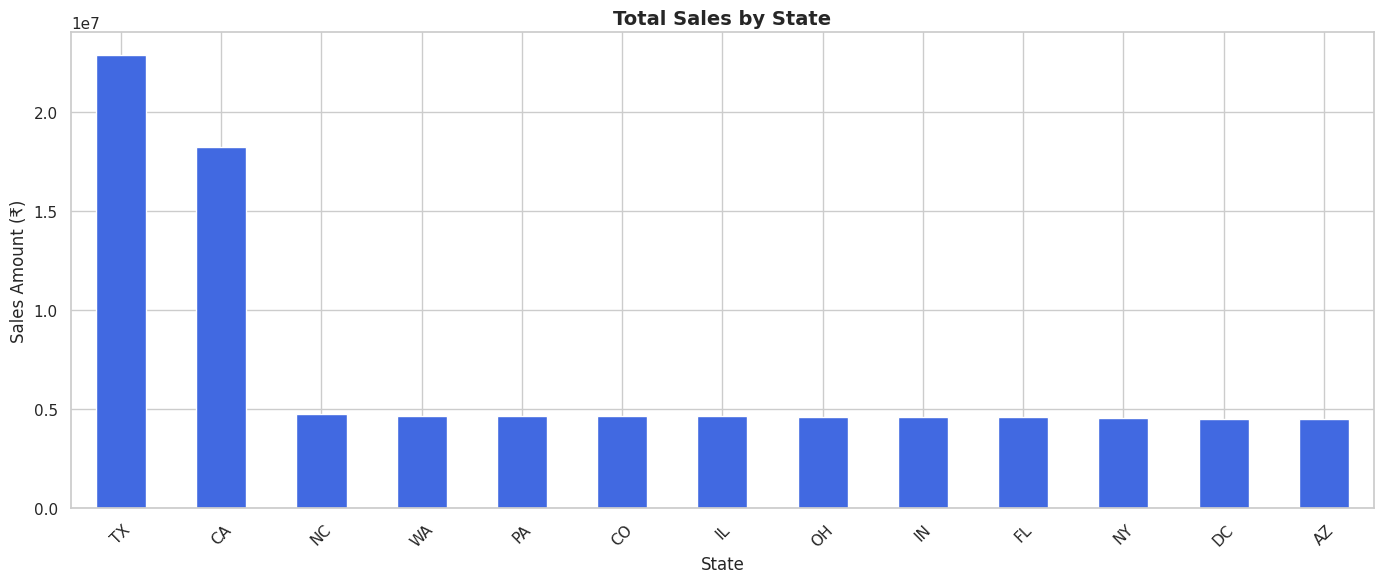

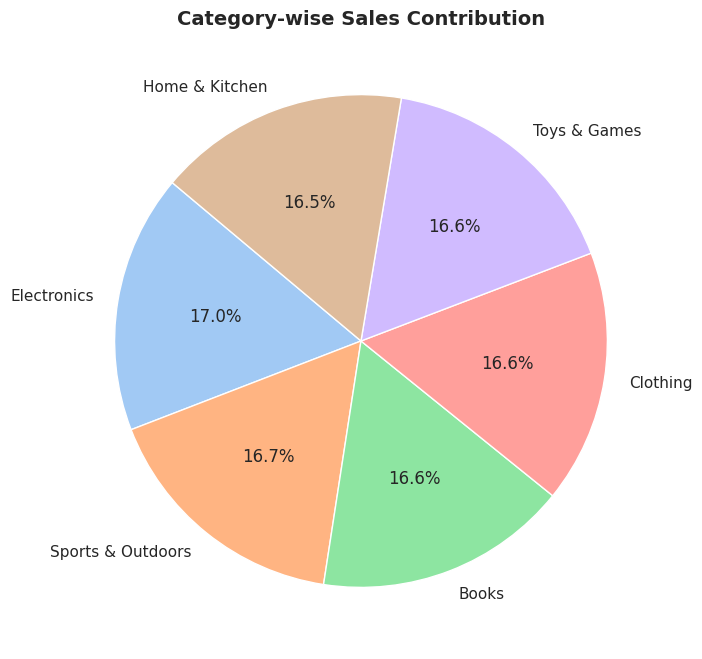

In [18]:
# Visualizations - State and Category (Q15 & Q16)
# Q15: Bar Chart Showing Sales by State
plt.figure(figsize=(14, 6))
state_sales.plot(kind='bar', color='royalblue')
plt.title('Total Sales by State', fontsize=14, fontweight='bold')
plt.ylabel('Sales Amount (₹)')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Q16: Pie Chart Showing Category-wise Sales
plt.figure(figsize=(8, 8))
cat_sales.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Category-wise Sales Contribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

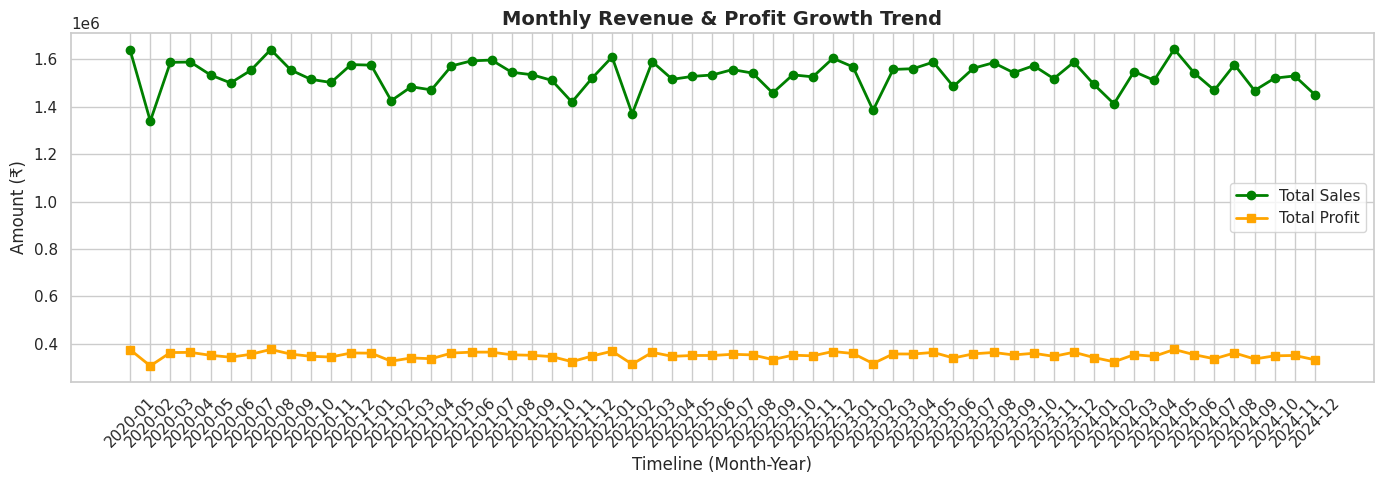

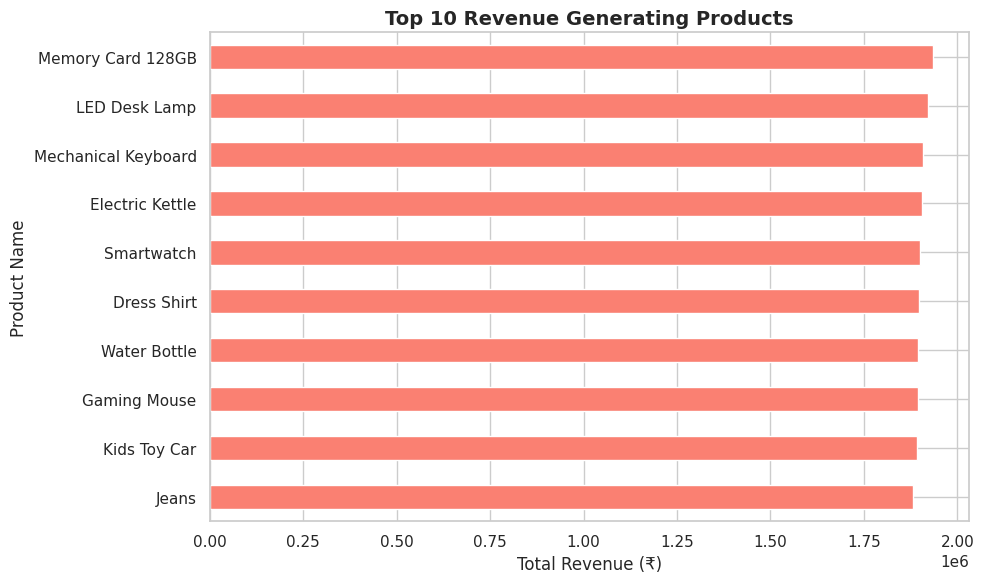

In [19]:
# Visualizations - Trends and Products (Q17 & Q18)
# Q17: Line Chart Showing Monthly Sales Trend
monthly_trend_sorted = monthly_trend.sort_index()
plt.figure(figsize=(14, 5))
plt.plot(monthly_trend_sorted.index.astype(str), monthly_trend_sorted['TotalAmount'], marker='o', linewidth=2, color='green', label='Total Sales')
plt.plot(monthly_trend_sorted.index.astype(str), monthly_trend_sorted['Profit'], marker='s', linewidth=2, color='orange', label='Total Profit')
plt.title('Monthly Revenue & Profit Growth Trend', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Month-Year)')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Q18: Horizontal Bar Chart Showing Top 10 Products by Sales
plt.figure(figsize=(10, 6))
top_10_products = df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=True).tail(10)
top_10_products.plot(kind='barh', color='salmon')
plt.title('Top 10 Revenue Generating Products', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()